<h1>Train — InceptionNet v3</h1>

Trains and evaluates InceptionNet v3 using the tuned hyperparameters from `ARCH_HYPERPARAMS["inception_v3"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1850 | Val: 405 | Test: 252


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["inception_v3"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"InceptionNet v3: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

InceptionNet v3: micro batch = 4, accumulation steps = 4 (effective batch size ≈ 16, tuned value = 17)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with InceptionNet v3)
# ---------------------------------------------------------
model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)

in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

# The auxiliary classifier (used only during training, see run_epoch in
# wwtw_utils.py) also needs its output layer resized to our number of classes.
in_f_aux = model.AuxLogits.fc.in_features
model.AuxLogits.fc = nn.Linear(in_f_aux, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[InceptionNet v3] Using gradient accumulation: 4 micro-batches per optimizer step (effective batch size ≈ micro_batch x 4).
[InceptionNet v3] Epoch   1/100 | LR: 1.43e-04 | train loss 1.6097 acc 0.487 | val loss 0.9084 acc 0.622 *
[InceptionNet v3] Epoch   2/100 | LR: 1.43e-04 | train loss 1.2541 acc 0.618 | val loss 0.9455 acc 0.711
[InceptionNet v3] Epoch   3/100 | LR: 1.43e-04 | train loss 1.1748 acc 0.655 | val loss 0.8013 acc 0.679 *
[InceptionNet v3] Epoch   4/100 | LR: 1.43e-04 | train loss 1.0245 acc 0.695 | val loss 0.9973 acc 0.741
[InceptionNet v3] Epoch   5/100 | LR: 1.43e-04 | train loss 0.9901 acc 0.696 | val loss 1.2060 acc 0.677
[InceptionNet v3] Epoch   6/100 | LR: 1.43e-04 | train loss 0.9252 acc 0.723 | val loss 1.1696 acc 0.748
[InceptionNet v3] Epoch   7/100 | LR: 1.43e-04 | train loss 0.8897 acc 0.739 | val loss 1.2414 acc 0.610
[InceptionNet v3] Epoch   8/100 | LR: 1.43e-04 | train loss 0.7865 acc 0.783 | val loss 1.9564 acc 0.775
[InceptionNet v3] Epoch   9/100 

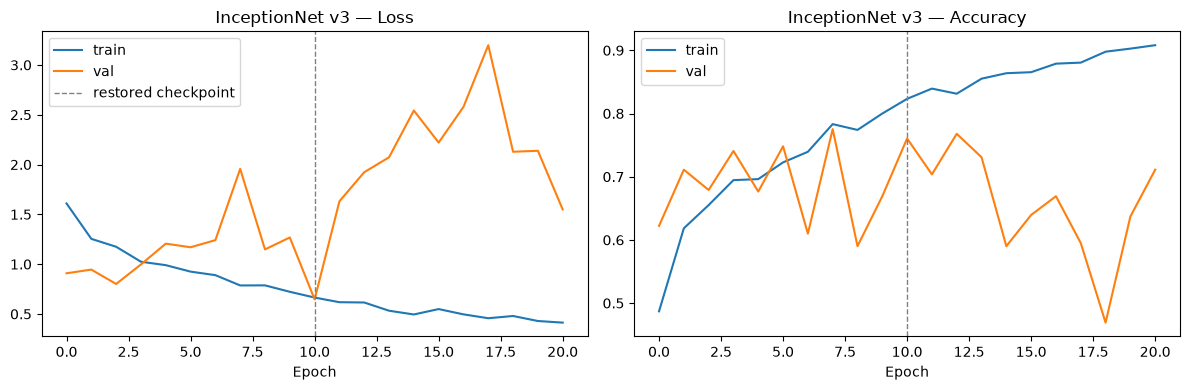

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "InceptionNet v3", is_inception=True,
    accum_steps=accum_steps,
)
plot_training_curves(history, "InceptionNet v3")

## Evaluate on the test set

[InceptionNet v3] Test accuracy: 0.587


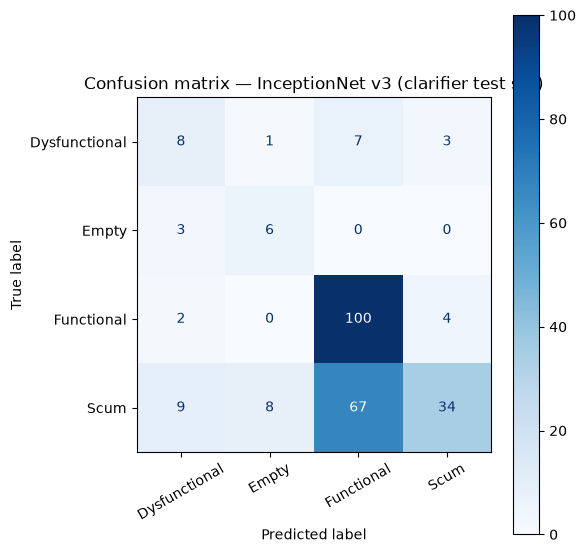

               precision    recall  f1-score   support

Dysfunctional      0.364     0.421     0.390        19
        Empty      0.400     0.667     0.500         9
   Functional      0.575     0.943     0.714       106
         Scum      0.829     0.288     0.428       118

     accuracy                          0.587       252
    macro avg      0.542     0.580     0.508       252
 weighted avg      0.672     0.587     0.548       252



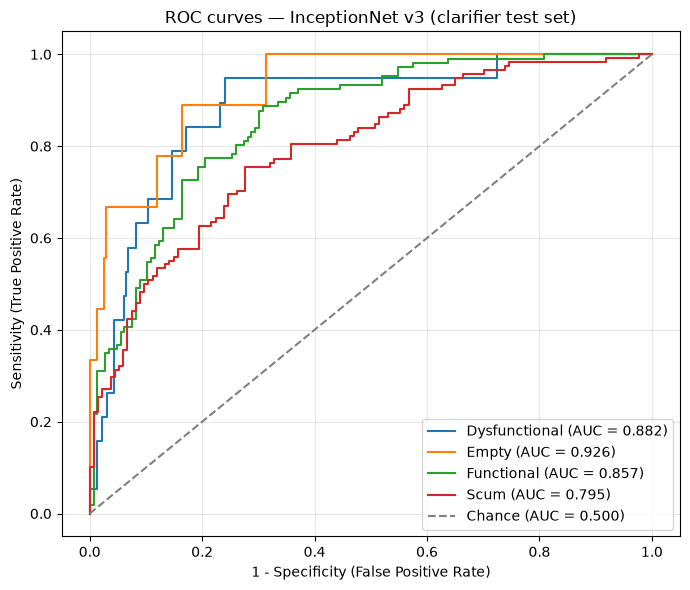

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.882
  Empty          : 0.926
  Functional     : 0.857
  Scum           : 0.795

Mean AUC: 0.865


(np.float64(0.5873015873015873),
 {'Dysfunctional': 0.8818613056245765,
  'Empty': 0.9263831732967536,
  'Functional': 0.8566813130007753,
  'Scum': 0.7945863900834809})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "InceptionNet v3", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("InceptionNet v3", "inception_v3")

Saved results to ../results/results_clarifier_inception_v3.pkl
Saved model weights to ../models/clarifier_inception_v3_cnn.pt
